# Regressão Linear: PIB x Índice ABCR

Investigação da relação entre a atividade econômica brasileira (PIB) e o fluxo de veículos nas rodovias pedagiadas (Índice ABCR), 2006-2025.

**Fontes:**
- IBGE – SIDRA, Tabela 1620: Índice de volume trimestral do PIB a preços de mercado (Base: média 1995=100), série sem ajuste sazonal, Brasil. https://sidra.ibge.gov.br/tabela/1620
- ABCR / Tendências Consultoria: Índice ABCR — fluxo total de veículos, série original, Brasil, base 1999=100. https://melhoresrodovias.org.br/indice-abcr_2/ (aba Brasil → Total → "Ver histórico")





In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.precision', 2)

In [2]:
pib_valores = [
    128.18, 132.13, 136.72, 136.37,
    134.84, 140.77, 144.75, 145.43,
    143.14, 149.69, 154.86, 146.92,
    139.67, 146.39, 153.06, 154.75,
    152.53, 158.86, 163.63, 163.55,
    160.45, 166.33, 169.41, 167.75,
    163.19, 167.97, 173.63, 171.91,
    167.63, 174.73, 178.42, 176.26,
    173.45, 173.97, 177.28, 175.86,
    170.64, 169.20, 169.72, 166.15,
    161.87, 163.75, 165.55, 162.39,
    162.33, 165.04, 168.27, 166.58,
    165.42, 167.71, 171.73, 169.17,
    166.91, 169.68, 173.64, 172.03,
    167.60, 152.48, 168.37, 171.46,
    170.53, 171.38, 175.46, 173.96,
    173.05, 177.45, 183.04, 178.65,
    180.74, 184.28, 187.35, 182.90,
    185.18, 190.68, 195.10, 189.45,
    191.02, 195.18, 198.66, 192.94,
]

anos = list(range(2006, 2026))
pib_trimestral = pd.DataFrame({
    'Ano': [a for a in anos for _ in range(4)],
    'Trimestre': [t for _ in anos for t in (1, 2, 3, 4)],
    'PIB_indice': pib_valores,
})
pib_trimestral.to_csv('pib_indice_trimestral.csv', index=False)
pib_trimestral.head()

,Ano,Trimestre,PIB_indice
0,2006,1,128.18
1,2006,2,132.13
2,2006,3,136.72
3,2006,4,136.37
4,2007,1,134.84


In [3]:
abcr_valores = [
    117.48, 100.13, 105.83, 104.45, 102.70, 97.75, 109.59, 106.10, 105.39, 108.58, 108.61, 123.28,
    120.23, 105.37, 110.96, 108.87, 107.98, 106.39, 115.47, 113.61, 114.95, 119.07, 115.94, 128.99,
    127.80, 113.44, 120.04, 115.63, 119.86, 114.01, 126.60, 119.78, 118.11, 122.54, 119.41, 133.70,
    127.57, 113.92, 118.05, 120.49, 120.43, 115.34, 124.99, 121.66, 122.61, 131.04, 125.36, 141.75,
    135.03, 120.32, 128.01, 126.84, 129.97, 123.75, 136.23, 134.07, 134.01, 138.64, 136.75, 153.81,
    149.00, 128.00, 139.93, 139.43, 136.97, 135.19, 144.82, 140.75, 138.98, 143.73, 142.15, 158.37,
    154.53, 140.97, 144.75, 142.73, 141.89, 137.84, 150.51, 148.31, 147.80, 151.96, 150.96, 163.40,
    161.94, 138.68, 151.65, 144.63, 150.09, 143.06, 157.66, 155.44, 152.40, 159.33, 158.58, 169.61,
    170.62, 147.90, 155.91, 154.80, 152.97, 144.38, 153.80, 158.42, 153.34, 161.88, 157.81, 174.97,
    170.73, 143.57, 152.09, 152.28, 149.82, 145.84, 157.08, 153.13, 151.14, 159.57, 147.83, 167.90,
    161.57, 145.55, 150.54, 146.02, 144.83, 137.47, 154.32, 145.67, 143.57, 147.80, 144.60, 165.02,
    161.76, 140.39, 150.09, 145.45, 146.58, 142.83, 158.31, 148.50, 151.29, 153.98, 148.45, 168.72,
    165.99, 141.19, 153.44, 149.52, 126.49, 137.54, 155.69, 149.18, 149.59, 152.52, 150.98, 169.33,
    170.56, 141.11, 153.30, 149.85, 149.05, 143.79, 159.65, 152.54, 155.04, 161.95, 155.76, 171.45,
    170.30, 146.92, 123.83, 82.40, 95.67, 110.28, 129.27, 134.63, 145.61, 156.09, 148.42, 162.35,
    155.08, 136.68, 127.11, 123.34, 139.17, 135.89, 152.50, 147.69, 148.80, 152.99, 150.94, 169.70,
    154.85, 140.96, 155.36, 150.78, 149.72, 142.59, 163.95, 155.63, 154.00, 158.39, 151.54, 171.71,
    173.89, 147.54, 162.73, 156.44, 158.54, 153.84, 170.51, 162.55, 164.61, 164.91, 163.35, 182.98,
    179.31, 157.48, 166.60, 161.02, 162.62, 160.43, 178.18, 168.96, 167.78, 171.70, 168.87, 183.56,
    183.89, 159.10, 170.53, 167.85, 168.14, 161.86, 180.31, 173.10, 171.67, 178.23, 172.64, 190.12,
]

abcr_mensal = pd.DataFrame({
    'Ano': [a for a in anos for _ in range(12)],
    'Mes': [m for _ in anos for m in range(1, 13)],
    'ABCR_indice': abcr_valores,
})
abcr_mensal.to_csv('abcr_indice_mensal.csv', index=False)
abcr_mensal.head()

,Ano,Mes,ABCR_indice
0,2006,1,117.48
1,2006,2,100.13
2,2006,3,105.83
3,2006,4,104.45
4,2006,5,102.70


In [4]:
pib_anual = pib_trimestral.groupby('Ano')['PIB_indice'].mean().round(2)
abcr_anual = abcr_mensal.groupby('Ano')['ABCR_indice'].mean().round(2)

dados = pd.DataFrame({'PIB_indice': pib_anual, 'ABCR_indice': abcr_anual}).reset_index()
dados.to_csv('dados_anuais.csv', index=False)

assert (pib_trimestral.groupby('Ano').size() == 4).all()
assert (abcr_mensal.groupby('Ano').size() == 12).all()
print("OK: 20 anos completos (2006-2025)")
dados

OK: 20 anos completos (2006-2025)


,Ano,PIB_indice,ABCR_indice
0,2006,133.35,107.49
1,2007,141.45,113.99
2,2008,148.65,120.91
3,2009,148.47,123.60
4,2010,159.64,133.12
5,2011,165.98,141.44
6,2012,169.18,147.97
7,2013,174.26,153.59
8,2014,175.14,157.23
9,2015,168.93,154.25


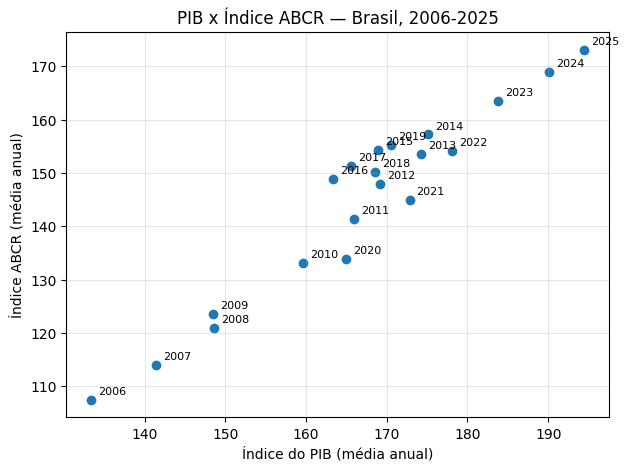

Correlação de Pearson: 0.9641


In [5]:
plt.figure(figsize=(7, 5))
plt.scatter(dados['PIB_indice'], dados['ABCR_indice'])
for _, linha in dados.iterrows():
    plt.annotate(int(linha['Ano']), (linha['PIB_indice'], linha['ABCR_indice']), textcoords="offset points", xytext=(5, 4), fontsize=8)
plt.xlabel('Índice do PIB (média anual)')
plt.ylabel('Índice ABCR (média anual)')
plt.title('PIB x Índice ABCR — Brasil, 2006-2025')
plt.grid(alpha=0.3)
plt.show()

correlacao = dados['PIB_indice'].corr(dados['ABCR_indice'])
print(f"Correlação de Pearson: {correlacao:.4f}")

In [6]:
treino = dados.iloc[:16]
teste = dados.iloc[16:]

X_treino, y_treino = treino[['PIB_indice']], treino['ABCR_indice']
X_teste, y_teste = teste[['PIB_indice']], teste['ABCR_indice']

modelo = LinearRegression()
modelo.fit(X_treino, y_treino)
previsoes = modelo.predict(X_teste)

print(f"ABCR_indice = {modelo.coef_[0]:.4f} * PIB_indice + ({modelo.intercept_:.4f})")

ABCR_indice = 1.2145 * PIB_indice + (-56.7835)


In [7]:
mae = mean_absolute_error(y_teste, previsoes)
mse = mean_squared_error(y_teste, previsoes)
r2 = r2_score(y_teste, previsoes)
print(f"MAE: {mae:.3f}  MSE: {mse:.3f}  R²: {r2:.3f}")

resultado = teste[['Ano', 'PIB_indice']].copy()
resultado['ABCR_observado'] = y_teste.values
resultado['ABCR_previsto'] = previsoes.round(2)
resultado['erro'] = (resultado['ABCR_observado'] - resultado['ABCR_previsto']).round(2)
resultado

MAE: 4.948  MSE: 25.939  R²: 0.485


,Ano,PIB_indice,ABCR_observado,ABCR_previsto,erro
16,2022,178.05,154.12,159.46,-5.34
17,2023,183.82,163.49,166.47,-2.98
18,2024,190.10,168.88,174.10,-5.22
19,2025,194.45,173.12,179.38,-6.26


## Conclusão

Correlação forte (~0,96) entre PIB e Índice ABCR: o fluxo de veículos pedagiados acompanha de perto a atividade econômica. O modelo (treino 2006-2021, teste 2022-2025) captura a tendência, mas tende a superestimar levemente o ABCR nos últimos anos — o fluxo cresceu um pouco menos que o PIB no pós-pandemia. Correlação alta não implica causalidade: os dois indicadores provavelmente respondem a fatores econômicos comuns.